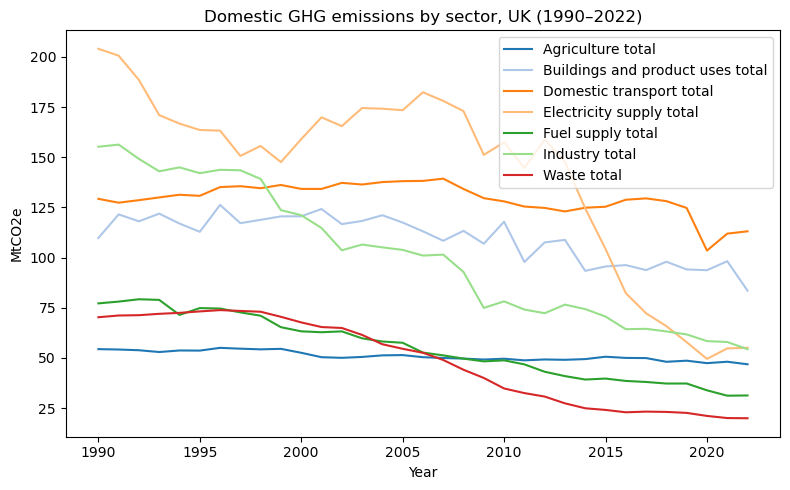

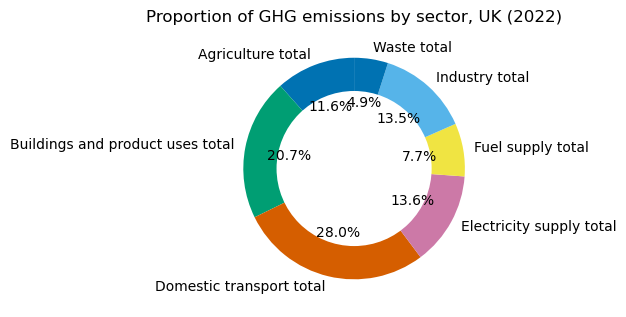

<Figure size 800x500 with 0 Axes>

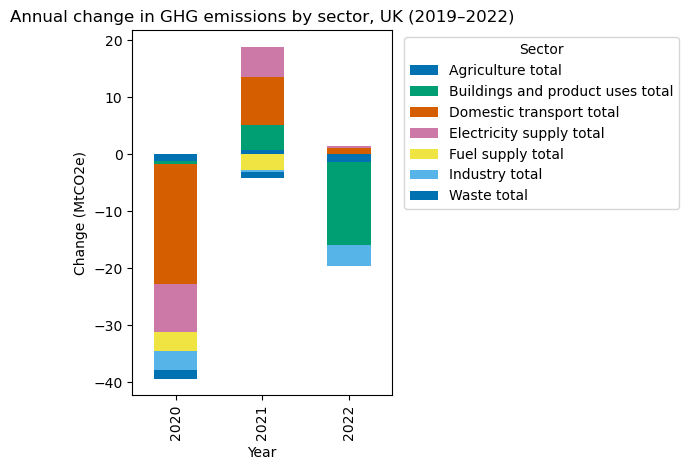

In [102]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────────────────────
# 1) File paths — adjust if needed
# ────────────────────────────────────────────────────────────────────────────────

desnz_file = 'final-greenhouse-gas-emissions-tables-2023.xlsx'

# ────────────────────────────────────────────────────────────────────────────────
# 2) Load and prepare sector data from DESNZ sheet '1.2' (Charts 1, 2 & 4)
# ────────────────────────────────────────────────────────────────────────────────
# Skip first 5 rows so header row becomes "TES sector","TES subsector","1990.0",… 
df_sec = pd.read_excel(desnz_file, sheet_name='1.2', skiprows=5)

# Identify sector / subsector columns
sector_col, subsector_col = df_sec.columns[0], df_sec.columns[1]

# Keep only top-level sectors
df_sec = df_sec[df_sec[subsector_col].isna()]

# Detect year columns 1990–2022
year_cols = [col for col in df_sec.columns[2:]
             if str(col).replace('.0','').isdigit() and 1990 <= int(float(col)) <= 2022]

# Build numeric-year DataFrame, then group by sector (to squash any duplicates)
df_sec_plot = (
    df_sec
    .set_index(sector_col)[year_cols]
    .groupby(level=0)
    .sum()
)

# Clean up column headers
df_sec_plot.columns = [int(float(c)) for c in df_sec_plot.columns]

# ─ Exclude 'LULUCF Total' and 'Grand Total' ─
excluded = ['LULUCF total', 'Grand total']
df_sec_plot = df_sec_plot[~df_sec_plot.index.isin(excluded)]

# ─ Chart 1: Domestic GHG emissions by sector (1990–2022) ────────────────────────
plt.figure(figsize=(8,5))
colors = plt.cm.tab20.colors  # or use 'tab10', 'Set3', etc.
for i, (sec, row) in enumerate(df_sec_plot.iterrows()):
    plt.plot(df_sec_plot.columns, row.values, label=sec, color=colors[i % len(colors)])
plt.title('Domestic GHG emissions by sector, UK (1990–2022)')
plt.xlabel('Year'); plt.ylabel('MtCO2e')
plt.legend(loc='best'); plt.tight_layout(); plt.show()

# ─ Chart 2: Proportion of emissions by sector, 2022 (Doughnut) ─────────────────
share22 = df_sec_plot.loc[:, 2022] / df_sec_plot.loc[:, 2022].sum() * 100
plt.figure(figsize=(6,6))
plt.pie(share22, labels=share22.index, autopct='%1.1f%%', startangle=90)
centre = plt.Circle((0,0),0.70,fc='white'); plt.gca().add_artist(centre)
plt.title('Proportion of GHG emissions by sector, UK (2022)')
plt.tight_layout(); plt.show()

# ─ Chart 4: Annual change in emissions by sector (2019–2022) ────────────────────
changes = pd.DataFrame({
    yr: df_sec_plot[yr] - df_sec_plot[yr-1]
    for yr in (2020, 2021, 2022)
})
plt.figure(figsize=(8,5))
changes.T.plot(kind='bar', stacked=True)
plt.title('Annual change in GHG emissions by sector, UK (2019–2022)')
plt.xlabel('Year'); plt.ylabel('Change (MtCO2e)')
plt.legend(title='Sector', bbox_to_anchor=(1.02,1)); plt.tight_layout(); plt.show()





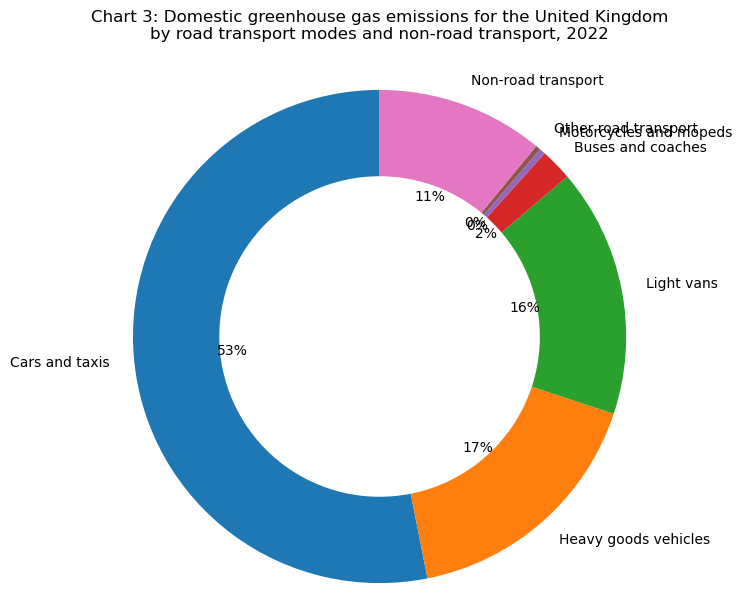


Table 1: Domestic and international greenhouse gas emissions
(MtCO2e) for the United Kingdom by transport mode, 1990, 2021 and 2022

                                              1990  2021  2022
Transport type                                                
Total domestic transport                     129.3 111.9 113.1
International aviation                        15.5  13.8  28.4
International shipping                         8.1   6.2   6.3
Total transport (domestic and international) 152.9 131.9 147.7
Cars and taxis                                72.3  57.8  60.1
HGVs                                          21.3  20.3  19.0
Light vans                                    11.3  18.7  18.4
Buses and coaches                              5.3   2.4   2.4
Motorcycles and mopeds                         0.7   0.4   0.5
Other road transport                           0.0   0.3   0.4
Rail                                           2.0   1.6   1.5
Domestic aviation                              

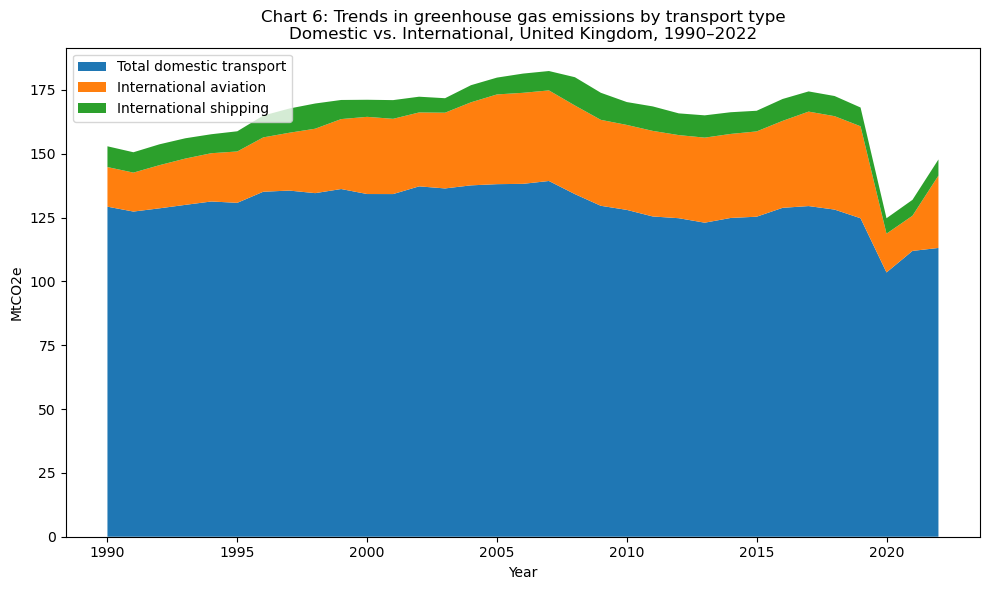

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ——————————————————————————————————————————
# 1) Load the data and detect header row
# ——————————————————————————————————————————
file_path = 'env0201.xlsx'
raw = pd.read_excel(file_path, sheet_name='ENV0201a_source', header=None)
header_row = raw[raw.iloc[:, 0] == 'Transport type and mode'].index[0]
df = pd.read_excel(file_path, sheet_name='ENV0201a_source', header=header_row)

# Rename for convenience
df.rename(columns={df.columns[0]: 'Mode'}, inplace=True)


# ——————————————————————————————————————————
# 2) Chart 3: Doughnut of 2022 emissions by mode
# ——————————————————————————————————————————
# select the six road-modes + total non-road transport
modes3 = [
    'Domestic road transport, Cars and taxis',
    'Domestic road transport, Heavy goods vehicles',
    'Domestic road transport, Light vans',
    'Domestic road transport, Buses and coaches',
    'Domestic road transport, Motorcycles and mopeds',
    'Domestic road transport, Other [note 4]',
    'Total domestic non-road transport'
]
data3 = df.loc[df['Mode'].isin(modes3), ['Mode', '2022 (MtCO2e)']].set_index('Mode')

# map to exactly the labels used on GOV.UK
label_map3 = {
    'Domestic road transport, Cars and taxis':       'Cars and taxis',
    'Domestic road transport, Heavy goods vehicles': 'Heavy goods vehicles',
    'Domestic road transport, Light vans':           'Light vans',
    'Domestic road transport, Buses and coaches':    'Buses and coaches',
    'Domestic road transport, Motorcycles and mopeds':'Motorcycles and mopeds',
    'Domestic road transport, Other [note 4]':       'Other road transport',
    'Total domestic non-road transport':             'Non-road transport'
}
chart3 = data3.rename(index=label_map3)

fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(
    chart3['2022 (MtCO2e)'],
    labels=chart3.index,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'width': 0.35}
)
ax.set_title(
    'Chart 3: Domestic greenhouse gas emissions for the United Kingdom\n'
    'by road transport modes and non-road transport, 2022',
    pad=20
)
ax.axis('equal')
plt.show()


# ——————————————————————————————————————————
# 3) Chart 5: Grouped bars for 1990, 2021, 2022
# ——————————————————————————————————————————
# main categories
majors = [
    ('Domestic road transport, Cars and taxis',       'Cars and taxis'),
    ('Domestic road transport, Heavy goods vehicles', 'HGVs'),
    ('Domestic road transport, Light vans',           'Light vans'),
    ('Domestic road transport, Buses and coaches',    'Buses and coaches'),
]

# “Other domestic category” sum
others = [
    'Domestic road transport, Motorcycles and mopeds',
    'Domestic road transport, Other [note 4]',
    'Domestic non-road transport, Rail',
    'Domestic non-road transport, Aviation',
    'Domestic non-road transport, Other [note 6]'
]

# extract the three years
years = ['1990 (MtCO2e)', '2021 (MtCO2e)', '2022 (MtCO2e)']
labels5 = [lab for _, lab in majors] + ['Other domestic category', 'International aviation', 'International shipping']
vals = []

# majors
for full, lab in majors:
    vals.append(df.loc[df['Mode'] == full, years].iloc[0].values)

# other domestic
vals.append(df.loc[df['Mode'].isin(others), years].sum().values)

# internationals
vals.append(df.loc[df['Mode']=='International aviation [note 7]', years].iloc[0].values)
vals.append(df.loc[df['Mode']=='International shipping [note 7]', years].iloc[0].values)

vals = np.array(vals)
x = np.arange(len(labels5))
w = 0.25



# ——————————————————————————————————————————
# 4) Table 1: Domestic & international emissions, 1990, 2021, 2022
# ——————————————————————————————————————————
# pick out each row and compute total transport
rows = {
    'Total domestic transport': df.loc[df['Mode']=='Total domestic transport', years].iloc[0],
    'International aviation':   df.loc[df['Mode']=='International aviation [note 7]', years].iloc[0],
    'International shipping':   df.loc[df['Mode']=='International shipping [note 7]', years].iloc[0],
}
# compute total transport = domestic + aviation + shipping
total_trans = rows['Total domestic transport'] + rows['International aviation'] + rows['International shipping']
rows['Total transport (domestic and international)'] = total_trans

# now individual modes
ind_modes = [
    ('Domestic road transport, Cars and taxis',       'Cars and taxis'),
    ('Domestic road transport, Heavy goods vehicles', 'HGVs'),
    ('Domestic road transport, Light vans',           'Light vans'),
    ('Domestic road transport, Buses and coaches',    'Buses and coaches'),
    ('Domestic road transport, Motorcycles and mopeds','Motorcycles and mopeds'),
    ('Domestic road transport, Other [note 4]',       'Other road transport'),
    ('Domestic non-road transport, Rail',             'Rail'),
    ('Domestic non-road transport, Aviation',         'Domestic aviation'),
    ('Domestic non-road transport, Shipping [note 5]','Domestic shipping'),
    ('Domestic non-road transport, Other [note 6]',   'Other non-road transport')
]
for full, lab in ind_modes:
    rows[lab] = df.loc[df['Mode']==full, years].iloc[0]

# build DataFrame
table1 = pd.DataFrame(rows).T
table1.index.name = 'Transport type'
table1.columns = ['1990', '2021', '2022']

print('\nTable 1: Domestic and international greenhouse gas emissions\n'
      '(MtCO2e) for the United Kingdom by transport mode, 1990, 2021 and 2022\n')
print(table1.to_string(float_format='%.1f'))

# ——————————————————————————————————————————
# 5) Chart 6: Stacked area of total domestic vs international, 1990–2022
# ——————————————————————————————————————————
# Identify all year columns up to 2022
year_cols = [c for c in df.columns if c.endswith('(MtCO2e)')]
years_int = sorted(int(c.split()[0]) for c in year_cols if int(c.split()[0]) <= 2022)
cols_6 = [f'{y} (MtCO2e)' for y in years_int]

# Extract the three series
domestic = df.loc[df['Mode']=='Total domestic transport', cols_6].iloc[0].values
intl_avi = df.loc[df['Mode']=='International aviation [note 7]', cols_6].iloc[0].values
intl_ship= df.loc[df['Mode']=='International shipping [note 7]', cols_6].iloc[0].values

# Plot
fig, ax = plt.subplots(figsize=(10,6))
ax.stackplot(
    years_int,
    domestic,
    intl_avi,
    intl_ship,
    labels=[
        'Total domestic transport',
        'International aviation',
        'International shipping'
    ]
)
ax.set_xlabel('Year')
ax.set_ylabel('MtCO2e')
ax.set_title(
    'Chart 6: Trends in greenhouse gas emissions by transport type\n'
    'Domestic vs. International, United Kingdom, 1990–2022'
)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()



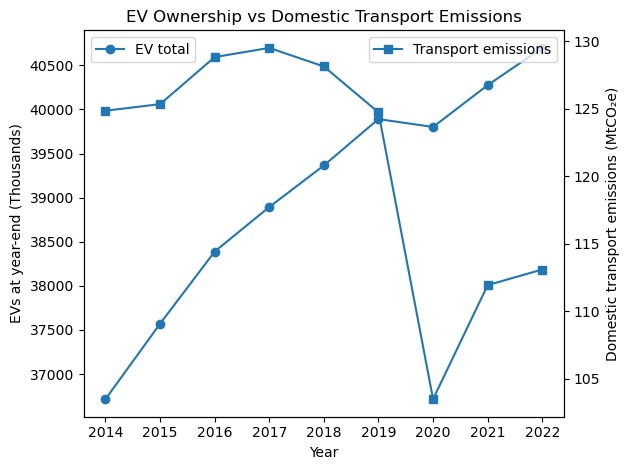

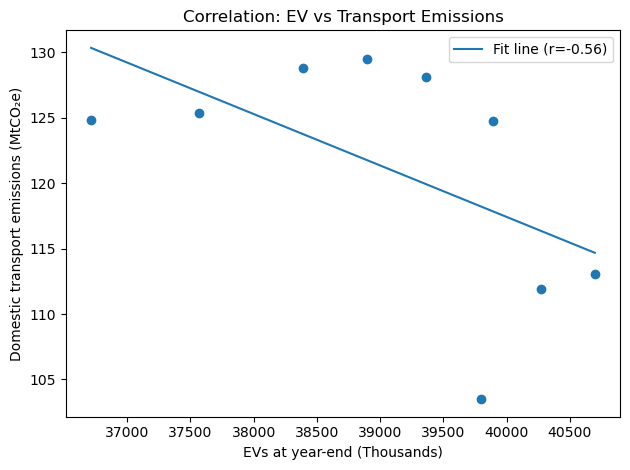

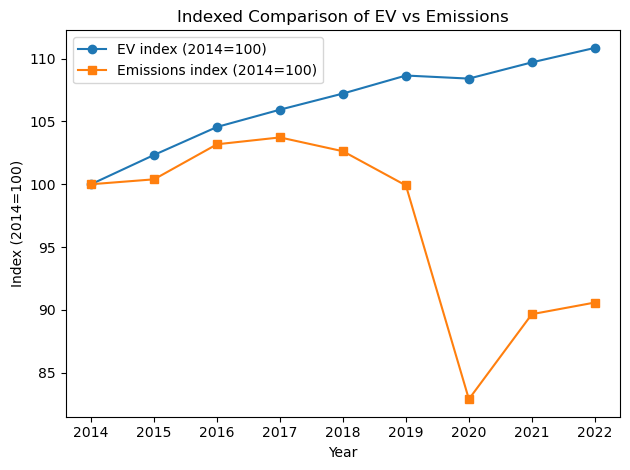

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1) Load sector emissions properly
desnz_file = 'final-greenhouse-gas-emissions-tables-2023.xlsx'
df_sec = pd.read_excel(desnz_file, sheet_name='1.2', skiprows=5)
sec_col, sub_col = df_sec.columns[0], df_sec.columns[1]
df_sec = df_sec[df_sec[sub_col].isna()]
year_cols = [col for col in df_sec.columns[2:]
             if str(col).replace('.0','').isdigit() and 1990 <= int(float(col)) <= 2022]
df_sec_plot = (df_sec.set_index(sec_col)[year_cols]
               .groupby(level=0).sum())
# Convert column names to ints
df_sec_plot.columns = [int(float(c)) for c in df_sec_plot.columns]
# Extract domestic transport emissions
dom_em = df_sec_plot.loc['Domestic transport total']

# 2) Load EV data
ev_file = 'veh0101.xlsx'
df_ev = pd.read_excel(ev_file, sheet_name='VEH0101a_Lic', skiprows=4)
uk_ev = df_ev[(df_ev['Geography [note 1]']=='United Kingdom') &
             (df_ev['Units']=='Thousands') &
             df_ev['Date'].str.contains('Q4')].copy()
uk_ev['Year'] = uk_ev['Date'].str.extract(r'(\d{4})').astype(int)
ev_series = uk_ev.set_index('Year')['Total'].astype(float)

# 3) Align on common years
common = sorted(set(dom_em.index) & set(ev_series.index))
em_vals = dom_em.loc[common]
ev_vals = ev_series.loc[common]

# 4a) Dual-axis line chart
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(common, ev_vals.values, label='EV total', marker='o')
ax2.plot(common, em_vals.values, label='Transport emissions', marker='s')
ax1.set_xlabel('Year')
ax1.set_ylabel('EVs at year-end (Thousands)')
ax2.set_ylabel('Domestic transport emissions (MtCO₂e)')
plt.title('EV Ownership vs Domestic Transport Emissions')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 4b) Scatter with regression and r-value
slope, intercept, r_val, p_val, _ = linregress(ev_vals, em_vals)
x = np.linspace(ev_vals.min(), ev_vals.max(), 100)
y_fit = intercept + slope * x
plt.figure()
plt.scatter(ev_vals, em_vals)
plt.plot(x, y_fit, label=f'Fit line (r={r_val:.2f})')
plt.xlabel('EVs at year-end (Thousands)')
plt.ylabel('Domestic transport emissions (MtCO₂e)')
plt.title('Correlation: EV vs Transport Emissions')
plt.legend()
plt.tight_layout()
plt.show()

# 4c) Indexed comparison (2014=100)
ev_idx = ev_vals / ev_vals.iloc[0] * 100
em_idx = em_vals / em_vals.iloc[0] * 100
plt.figure()
plt.plot(common, ev_idx.values, label='EV index (2014=100)', marker='o')
plt.plot(common, em_idx.values, label='Emissions index (2014=100)', marker='s')
plt.xlabel('Year')
plt.ylabel('Index (2014=100)')
plt.title('Indexed Comparison of EV vs Emissions')
plt.legend()
plt.tight_layout()
plt.show()